## Titolo del progetto
Astronomical Analysis Enhanced

## Studente / Gruppo
Fabian Calangiu -- fabian.calangiu@studio.unibo.it

Manuel Menghetti -- manuel.menghetti@studio.unibo.it

# 1. Introduzione del problema

L'obiettivo del progetto è sviluppare modelli di classificazione e regressione in grado di
distinguere la tipologia di oggetto spaziale, ovvero:

- GALAXY; 
- STAR;
- QSO.

La analisi vengono effettuate utilizzando le bande fotometriche, rappresentate dalle magnitudini osservate nelle bande u, g, r, i, z.

I modelli utilizzati sono:

- Logistic Regression, utilizzata come modello lineare di riferimento;
- Random Forest Classifier, utilizzata come modello non lineare;

Il confronto viene effettuato utilizzando metriche di Precision, Recall, F1-score, Accuracy, Confusion Matrix. Questo ci permette di alsi positivi e falsi negativi.

Particolare attenzione viene dedicata allo sbilanciamento delle classi e al ruolo
del redshift. Quest'ultimo presenta una forte relazione con la tipologia
dell'oggetto astronomico; per tale motivo verranno distinti due scenari:

1. classificazione basata esclusivamente sulle informazioni fotometriche;
2. classificazione con l'inclusione del redshift.

Questo confronto permette di valutare quanto il redshift influenzi le prestazioni
del modello e di distinguere una classificazione puramente fotometrica da una
classificazione basata sull'insieme delle informazioni disponibili.


# 2. Descrizione del dataset

Il dataset utilizzato contiene osservazioni astronomiche provenienti dalla
Sloan Digital Sky Survey (SDSS) e raccoglie informazioni fotometriche,
spettroscopiche e identificative relative a differenti oggetti celesti.

Ogni riga rappresenta un singolo oggetto astronomico, classificato in una delle
seguenti categorie:

- Galassie;
- Stelle;
- Quasar, ossia nuclei galattici attivi estremamente luminosi.

Il dataset contiene 100.000 osservazioni e 18 variabili. Le colonne possono
essere suddivise in quattro gruppi principali:

1. variabili identificative;
2. coordinate celesti;
3. misure fotometriche;
4. misure spettroscopiche e informazioni sull'osservazione.

## 2.1 Descrizione delle variabili

| Variabile | Descrizione | Tipologia |
|---|---|---|
| `obj_ID` | Identificativo univoco dell'oggetto | Identificativa |
| `alpha` | Ascensione retta dell'oggetto | Coordinata celeste |
| `delta` | Declinazione dell'oggetto | Coordinata celeste |
| `u` | Magnitudine nella banda ultravioletta | Fotometrica |
| `g` | Magnitudine nella banda verde | Fotometrica |
| `r` | Magnitudine nella banda rossa | Fotometrica |
| `i` | Magnitudine nel vicino infrarosso | Fotometrica |
| `z` | Magnitudine nell'infrarosso | Fotometrica |
| `run_ID` | Identificativo della sessione osservativa | Tecnica/identificativa |
| `rerun_ID` | Identificativo della rielaborazione dei dati | Tecnica/identificativa |
| `cam_col` | Colonna della camera utilizzata | Tecnica |
| `field_ID` | Identificativo del campo osservato | Tecnica/identificativa |
| `spec_obj_ID` | Identificativo dell'osservazione spettroscopica | Identificativa |
| `class` | Classe astronomica dell'oggetto | Target |
| `redshift` | Spostamento verso il rosso osservato | Spettroscopica |
| `plate` | Identificativo della piastra spettroscopica | Tecnica |
| `MJD` | Data giuliana modificata dell'osservazione | Temporale |
| `fiber_ID` | Identificativo della fibra spettroscopica | Tecnica |

Per rendere il codice più leggibile, alcune variabili fotometriche verranno
successivamente rinominate:

| Originale | Nuovo           |
|-----------|-----------------|
| `u`       | `ultraviolet`   |
| `g`       | `green`         |
| `r`       | `red`           |
| `i`       | `near_infrared` |
| `z`       | `infrared`      |

## 2.2 Variabile target

La variabile target è `class`, che rappresenta la categoria astronomica
associata a ciascuna osservazione.

Il problema è quindi una classificazione supervisionata multiclasse, poiché
il modello deve assegnare ogni oggetto a una tra tre possibili categorie:
GALAXY, STAR oppure QSO.

La distribuzione delle classi non è uniforme. La classe GALAXY è maggioritaria,
mentre STAR e QSO presentano una numerosità inferiore. Questo aspetto rende
necessario valutare i modelli con metriche specifiche per ciascuna classe,
come Precision, Recall e F1-score, evitando di affidarsi esclusivamente
all'Accuracy.

## 2.3 Variabili fotometriche

Le magnitudini `u`, `g`, `r`, `i` e `z` rappresentano la luminosità apparente
degli oggetti osservata attraverso differenti filtri dello spettro
elettromagnetico.

Le differenze tra le magnitudini, comunemente definite indici di colore,
permettono di descrivere la forma dello spettro dell'oggetto:

- `u-g`;
- `g-r`;
- `r-i`;
- `i-z`.

Queste differenze costituiscono variabili particolarmente significative per la
classificazione, poiché stelle, galassie e quasar possono presentare
distribuzioni di colore differenti.

Nel progetto verranno pertanto considerate sia le magnitudini originali sia
gli indici di colore derivati.

## 2.3 Variabili fotometriche

Le magnitudini `u`, `g`, `r`, `i` e `z` rappresentano la luminosità apparente
degli oggetti osservata attraverso differenti filtri dello spettro
elettromagnetico.

Le differenze tra le magnitudini, comunemente definite indici di colore,
permettono di descrivere la forma dello spettro dell'oggetto:

- `u-g`;
- `g-r`;
- `r-i`;
- `i-z`.

Queste differenze costituiscono variabili particolarmente significative per la
classificazione, poiché stelle, galassie e quasar possono presentare
distribuzioni di colore differenti.

Nel progetto verranno pertanto considerate sia le magnitudini originali sia
gli indici di colore derivati.

## 2.4 Variabili identificative e tecniche

Le colonne identificative, come `obj_ID` e `spec_obj_ID`, non descrivono
proprietà fisiche dell'oggetto e non verranno utilizzate come variabili
predittive.

Anche alcune informazioni tecniche relative all'acquisizione dei dati,
come `run_ID`, `rerun_ID`, `field_ID`, `plate`, `MJD` e `fiber_ID`,
verranno inizialmente escluse dal modello.

La loro inclusione potrebbe infatti consentire al classificatore di apprendere
associazioni specifiche del processo osservativo anziché caratteristiche
astronomiche generalizzabili.

## 2.5 Ruolo del redshift

La variabile `redshift` rappresenta lo spostamento delle righe spettrali
dell'oggetto rispetto alla loro posizione di riferimento.

Questa variabile è fortemente associata alla natura dell'oggetto astronomico:
le stelle appartenenti alla Via Lattea presentano generalmente valori prossimi
allo zero, mentre galassie e quasar possono raggiungere valori più elevati.

Per valutare l'effettivo contributo del redshift verranno considerati due
scenari sperimentali:

1. **classificazione fotometrica**, basata sulle magnitudini e sugli indici
   di colore, senza utilizzare il redshift;

2. **classificazione estesa**, nella quale il redshift viene incluso tra
   le variabili predittive.

Il confronto permetterà di quantificare il miglioramento delle prestazioni
derivante dall'informazione spettroscopica.

### 3.1 Caricamento librerie mecessarie:

In [114]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    mean_absolute_error,
    r2_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    root_mean_squared_error,
    root_mean_squared_log_error
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE

data_path = "../data/star_classification.csv"

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")


Lettura Dataset:

In [115]:
df_raw = pd.read_csv(data_path)
df = df_raw.copy()

print(f"Dimensioni iniziali: {df.shape}")

Dimensioni iniziali: (100000, 18)


In [116]:
df.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [117]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  str    
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7), str(1)
mem

Il dataset non presenta valori nulli, ma sarà comunque necessario verificarne la presenza di valori sentinella o misure non valide

In [118]:
df.describe()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
count,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.237665e+18,177.629117,24.135305,21.980468,20.531387,19.645762,19.084854,18.668810,4481.366060,301.0,3.511610,186.130520,5.783882e+18,0.576661,5137.009660,55588.647500,449.312740
std,8.438560e+12,96.502241,19.644665,31.769291,31.750292,1.854760,1.757895,31.728152,1964.764593,0.0,1.586912,149.011073,3.324016e+18,0.730707,2952.303351,1808.484233,272.498404
min,1.237646e+18,0.005528,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,109.000000,301.0,1.000000,11.000000,2.995191e+17,-0.009971,266.000000,51608.000000,1.000000
25%,1.237659e+18,127.518222,5.146771,20.352353,18.965230,18.135828,17.732285,17.460677,3187.000000,301.0,2.000000,82.000000,2.844138e+18,0.054517,2526.000000,54234.000000,221.000000
50%,1.237663e+18,180.900700,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,4188.000000,301.0,4.000000,146.000000,5.614883e+18,0.424173,4987.000000,55868.500000,433.000000
75%,1.237668e+18,233.895005,39.901550,23.687440,22.123767,21.044785,20.396495,19.921120,5326.000000,301.0,5.000000,241.000000,8.332144e+18,0.704154,7400.250000,56777.000000,645.000000
max,1.237681e+18,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,8162.000000,301.0,6.000000,989.000000,1.412694e+19,7.011245,12547.000000,58932.000000,1000.000000


Come previsto, vi sono presenti valori sentinella che successivamente gestiremo

### 3.2 Pulizia Dei Dati

Si rinominano le bande fotometriche u, g, r, i, z per rendere più leggibili le analisi successive:

In [119]:
band_names = {
    "u": "ultraviolet",
    "g": "green",
    "r": "red",
    "i": "near_infrared",
    "z": "infrared",
}

df = df.rename(columns=band_names)

Eliminazione colonne superflue per l'esplorazione dei dati:

In [120]:
useless_columns = ["run_ID", "rerun_ID", "cam_col", "fiber_ID", "field_ID"]
df = df.drop(columns=useless_columns)

print(f"Colonne escluse dall'analisi: {useless_columns}")


Colonne escluse dall'analisi: ['run_ID', 'rerun_ID', 'cam_col', 'fiber_ID', 'field_ID']


Si rimuovono le righe contenenti valori sentinella nelle bande fotometriche, perché non rappresentano misure valide

In [121]:
photometric_columns = [
    "ultraviolet",
    "green",
    "red",
    "near_infrared",
    "infrared",
]

valid_photometry = (df[photometric_columns] > -1000).all(axis=1)
removed_rows = (~valid_photometry).sum()

df = df.loc[valid_photometry].reset_index(drop=True)

print(f"Righe con valori sentinella rimosse: {removed_rows}")
print(f"Dimensioni dopo la pulizia: {df.shape}")

Righe con valori sentinella rimosse: 1
Dimensioni dopo la pulizia: (99999, 13)


### 3.3 Encoding

In [122]:
class_mapping = {"GALAXY": 0, "STAR": 1, "QSO": 2}

df_encoded = df.copy()
df_encoded["class"] = df_encoded["class"].map(class_mapping)

# 4. Visualizzazione ed EDA

### 4.1 Statistiche descrittive

In [123]:
df.describe()

,obj_ID,alpha,delta,ultraviolet,green,red,near_infrared,infrared,spec_obj_ID,redshift,plate,MJD
count,9.999900e+04,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,9.999900e+04,99999.000000,99999.000000,99999.000000
mean,1.237665e+18,177.628653,24.135552,22.080679,20.631583,19.645777,19.084865,18.768988,5.783903e+18,0.576667,5137.027890,55588.653687
std,8.438450e+12,96.502612,19.644608,2.251068,2.037384,1.854763,1.757900,1.765982,3.324026e+18,0.730709,2952.312485,1808.492217
min,1.237646e+18,0.005528,-18.785328,10.996230,10.498200,9.822070,9.469903,9.612333,2.995191e+17,-0.009971,266.000000,51608.000000
25%,1.237659e+18,127.517698,5.147477,20.352410,18.965240,18.135795,17.732280,17.460830,2.844137e+18,0.054522,2526.000000,54234.000000
50%,1.237663e+18,180.900527,23.646462,22.179140,21.099930,20.125310,19.405150,19.004600,5.614896e+18,0.424176,4987.000000,55869.000000
75%,1.237668e+18,233.895005,39.901582,23.687480,22.123775,21.044790,20.396510,19.921120,8.332365e+18,0.704172,7400.500000,56777.000000
max,1.237681e+18,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,1.412694e+19,7.011245,12547.000000,58932.000000


### 4.2 Distribuzione della variabile target

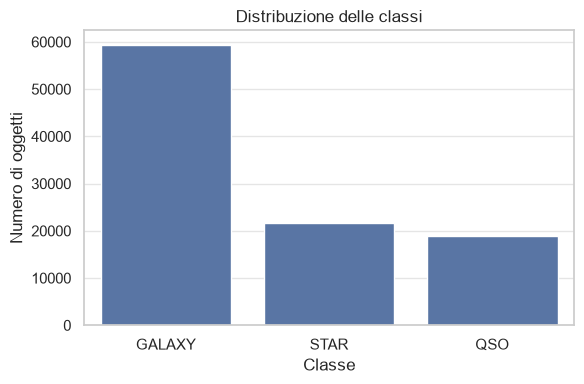

In [124]:
plt.figure(figsize=(6, 4))
sns.countplot(
    data=df,
    x="class",
    order=df["class"].value_counts().index,
    color=sns.color_palette()[0],
)
plt.title("Distribuzione delle classi")
plt.xlabel("Classe")
plt.ylabel("Numero di oggetti")
plt.tight_layout()
plt.show()

### 4.3 Distribuzione delle bande fotometriche

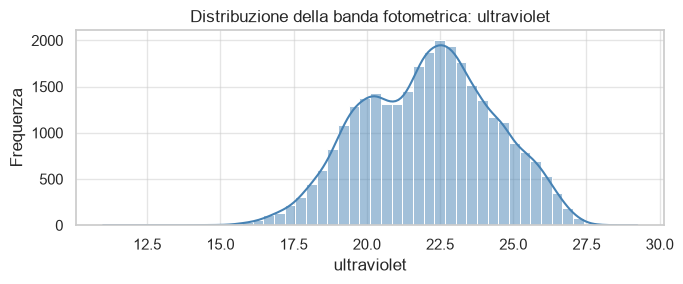

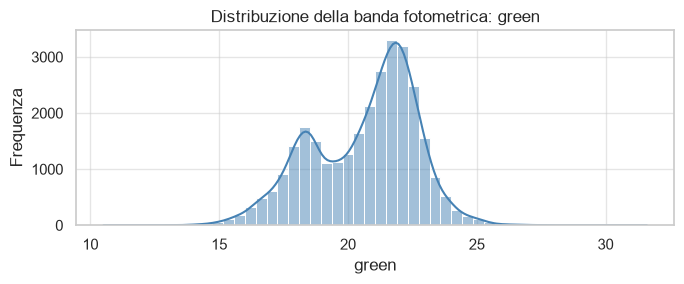

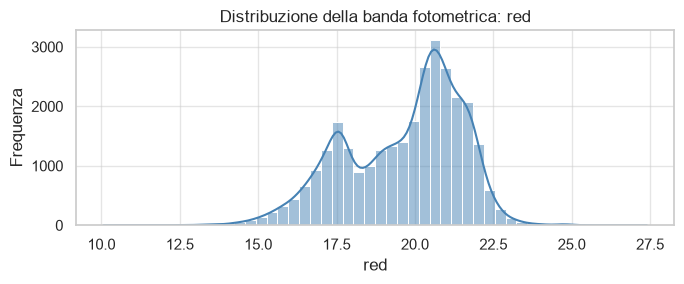

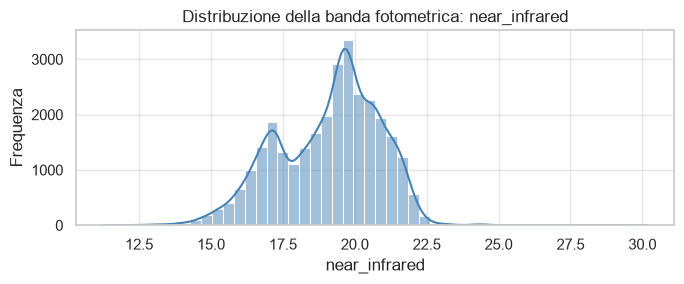

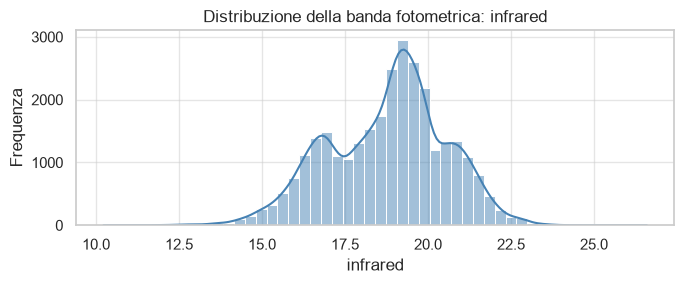

In [125]:
photometric_data = df[photometric_columns].sample(
    n=min(30_000, len(df)),
    random_state=RANDOM_STATE,
)

for column in photometric_columns:
    plt.figure(figsize=(7, 3))
    sns.histplot(
        data=photometric_data,
        x=column,
        kde=True,
        bins=50,
        color="steelblue",
    )
    plt.title(f"Distribuzione della banda fotometrica: {column}")
    plt.xlabel(column)
    plt.ylabel("Frequenza")
    plt.tight_layout()
    plt.show()

### 4.4 Correlation Matrix

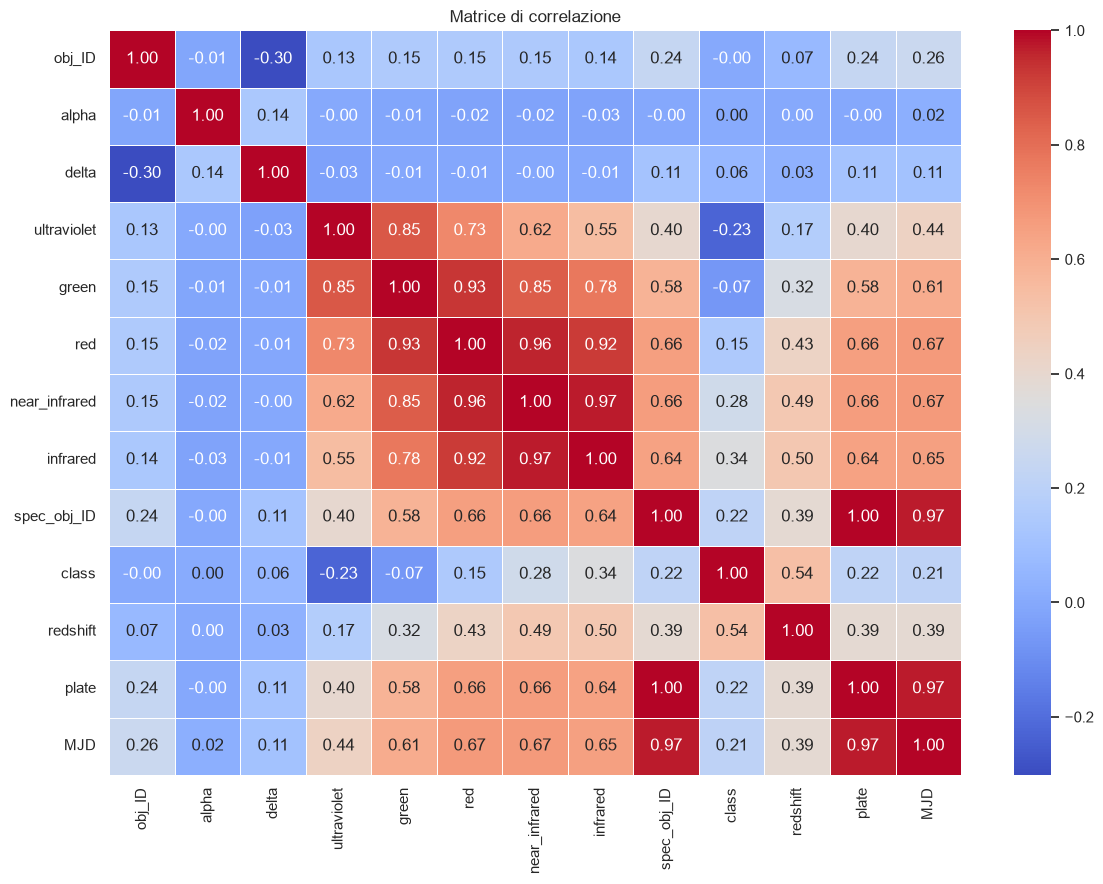

In [126]:
corr_matrix = df_encoded.corr(numeric_only=True)

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=True,
    linewidths=0.5,
    fmt=".2f",
)
plt.title("Matrice di correlazione")
plt.tight_layout()
plt.show()

<p>La mappa evidenzia una correlazione lineare tra le varie magnitudini (si noti verde con rosso, rosso con infrarosso e infrarosso vicino)</p>
<p>Vi è anche una discreta correlazione tra redshift, cioè lo spostamento dello spettro verso il rosso, e le magnitudini rosse o infrarosse. </p>
<p>La forte correlazione tra i restanti metadati (ID, plate dell'obiettivo e data di scatto) non è rilevante per l'analisi.</p>
<p>Infine, la posizione dell'oggetto nel piano celeste non mostra alcuna correlazione con i dati.</p>

### 4.5 Interpretazione degli indici di colore fotometrici

Le differenze tra le magnitudini osservate nelle diverse bande fotometriche, dette **indici di colore**, descrivono la distribuzione dell'energia emessa da un oggetto astronomico nelle varie regioni dello spettro elettromagnetico.

In generale:

- valori **positivi** indicano una maggiore emissione verso lunghezze d'onda più elevate (oggetti più rossi);
- valori **negativi** indicano una maggiore emissione verso lunghezze d'onda minori (oggetti più blu);
- valori **prossimi allo zero** indicano un'emissione simile nelle due bande considerate.

---

#### Indice `u - g` (Ultraviolet - Green)

L'indice **u-g** confronta la radiazione ultravioletta con quella nel visibile.

- **u-g > 0**
  - minore emissione nell'ultravioletto;
  - spettro relativamente povero di UV;
  - generalmente associato a stelle più fredde e galassie dominate da popolazioni stellari evolute.

- **u-g ≈ 0**
  - emissione simile nelle bande ultravioletta e verde;
  - spettro relativamente uniforme;
  - tipico di oggetti con temperatura intermedia.

- **u-g < 0**
  - emissione più intensa nell'ultravioletto;
  - spettro dominato da radiazione ad alta energia;
  - frequentemente osservato in stelle molto calde, regioni di intensa formazione stellare e quasar.

---

#### Indice `g - r` (Green - Red)

L'indice **g-r** descrive il colore nel visibile.

- **g-r > 0**
  - maggiore emissione nella banda rossa;
  - oggetti dal colore più rosso;
  - generalmente associato a stelle più fredde o popolazioni stellari più vecchie.

- **g-r ≈ 0**
  - emissione simile nelle bande verde e rossa;
  - colore intermedio.

- **g-r < 0**
  - maggiore emissione nella banda verde;
  - oggetti dal colore più blu;
  - tipico di stelle calde e popolazioni stellari giovani.

---

#### Indice `r - i` (Red - Near Infrared)

L'indice **r-i** confronta la banda rossa con il vicino infrarosso.

- **r-i > 0**
  - emissione crescente verso il vicino infrarosso;
  - spettro relativamente rosso;
  - frequentemente osservato in stelle fredde (tipi K-M) e galassie dominate da stelle evolute.

- **r-i ≈ 0**
  - emissione simile nelle due bande;
  - spettro relativamente uniforme.

- **r-i < 0**
  - emissione maggiore nella banda rossa;
  - spettro più blu;
  - caratteristico di stelle relativamente più calde.

---

#### Indice `i - z` (Near Infrared - Infrared)

L'indice **i-z** confronta le due bande più rosse del sistema SDSS.

- **i-z > 0**
  - maggiore emissione verso l'infrarosso;
  - oggetti molto rossi;
  - tipico di stelle molto fredde e di alcune galassie con popolazioni stellari evolute.

- **i-z ≈ 0**
  - emissione simile nelle due bande;
  - spettro quasi uniforme nel vicino infrarosso.

- **i-z < 0**
  - emissione relativamente maggiore nella banda *i*;
  - generalmente associato a oggetti più caldi o con significativa emissione alle lunghezze d'onda più corte, come alcuni quasar.

In [127]:
df["u_g"] = df["ultraviolet"] - df["green"]
df["g_r"] = df["green"] - df["red"]
df["r_i"] = df["red"] - df["near_infrared"]
df["i_z"] = df["near_infrared"] - df["infrared"]

In [128]:
color_columns = [
    "u_g",
    "g_r",
    "r_i",
    "i_z"
]

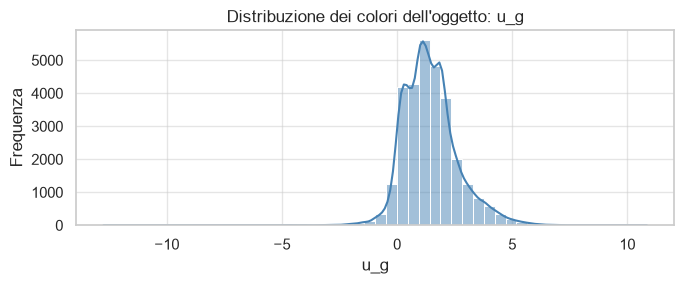

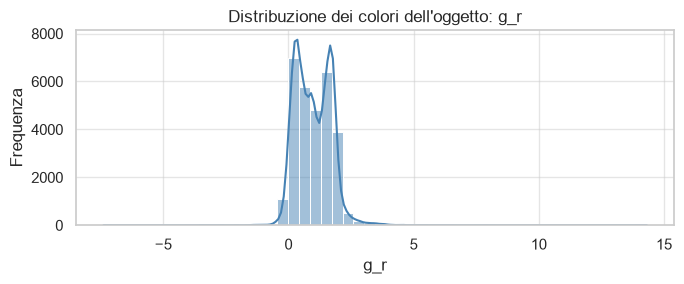

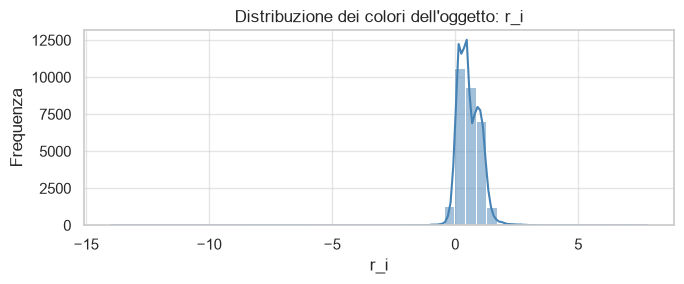

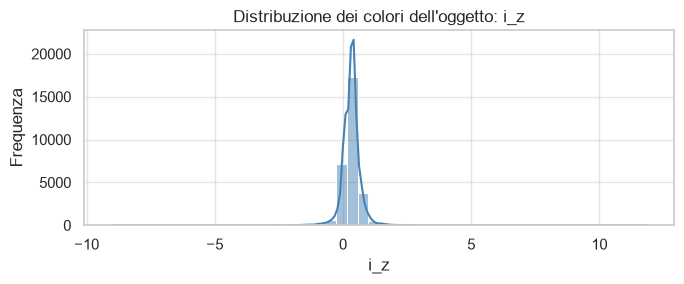

In [129]:
color_data = df[color_columns].sample(
    n=min(30_000, len(df)),
    random_state=RANDOM_STATE,
)

for column in color_columns:
    plt.figure(figsize=(7, 3))
    sns.histplot(
        data=color_data,
        x=column,
        kde=True,
        bins=50,
        color="steelblue",
    )
    plt.title(f"Distribuzione dei colori dell'oggetto: {column}")
    plt.xlabel(column)
    plt.ylabel("Frequenza")
    plt.tight_layout()
    plt.show()

Le distribuzioni degli indici di colore evidenziano comportamenti differenti tra le varie feature fotometriche. Gli indici `r-i` e `i-z` risultano maggiormente concentrati attorno a valori prossimi allo zero, indicando una variabilità contenuta tra le rispettive bande. L'indice `u-g` presenta invece una distribuzione più dispersa e asimmetrica, mentre `g-r` mostra una struttura bimodale che suggerisce la presenza di differenti popolazioni di oggetti astronomici.

Nel complesso, tali distribuzioni confermano che gli indici di colore rappresentano feature informative per il problema di classificazione, poiché descrivono differenti caratteristiche spettrali degli oggetti osservati e possono contribuire alla distinzione tra stelle, galassie e quasar.